<a href="https://colab.research.google.com/github/NavyaYadagiri/Big-Data-/blob/main/Big_Data_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing the required libraries

import pandas as pd
import numpy as np
import pyspark
from pyspark.sql import SparkSession
from pyspark import SparkContext, SparkConf
from datetime import datetime
import pytz
import string
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')
import numpy as np
import findspark
from pyspark.sql.types import IntegerType
from pyspark.ml.feature import VectorAssembler
findspark.init()

In [ ]:
pip install pyspark

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 281.4 MB 39 kB/s 
     |████████████████████████████████| 199 kB 44.6 MB/s 
  Created wheel for pyspark: filename=pyspark-3.3.1-py2.py3-none-any.whl size=281845512 sha256=0e269bfb841493ec1b9bdfa9e30d51ea336dc4a3254848327e8ed009a3cbfaa1
  Stored in directory: /root/.cache/pip/wheels/42/59/f5/79a5bf931714dcd201b26025347785f087370a10a3329a899c
Successfully built pyspark


In [ ]:
pip install findspark

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
#Connect to Google drive directories
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Setting up the directory folder
%cd /content/drive/MyDrive/IDS561_Final_Project/

/content/drive/MyDrive/IDS561_Final_Project


In [ ]:
#We are installing the JAVA to run the JVM so that Spark
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

In [ ]:
#Getting the Spark installer

!wget -v https://dlcdn.apache.org/spark/spark-3.1.3/spark-3.1.3-bin-hadoop3.2.tgz

--2022-11-28 18:27:57--  https://dlcdn.apache.org/spark/spark-3.1.3/spark-3.1.3-bin-hadoop3.2.tgz
Resolving dlcdn.apache.org (dlcdn.apache.org)... 151.101.2.132, 2a04:4e42::644
Connecting to dlcdn.apache.org (dlcdn.apache.org)|151.101.2.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 231842529 (221M) [application/x-gzip]
Saving to: ‘spark-3.1.3-bin-hadoop3.2.tgz’

spark-3.1.3-bin-had 100%[===================>] 221.10M  37.7MB/s    in 5.4s    

2022-11-28 18:28:03 (41.0 MB/s) - ‘spark-3.1.3-bin-hadoop3.2.tgz’ saved [231842529/231842529]



In [ ]:
#Untar the Spark installer
!tar -xvf spark-3.1.3-bin-hadoop3.2.tgz

#Install findspark - python library to find Spark
!pip install -q findspark

#Setting the environment variables
#Setting up the Java and Spark home by giving the file location
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/drive/MyDrive/HW4/spark-3.1.3-bin-hadoop3.2"

#Creating the local Spark session
import findspark
findspark.init()
from pyspark.sql import SparkSession
#spark = SparkSession.builder.master("local[*]").getOrCreate()

## initiating spark session

In [ ]:
session = SparkSession.builder.getOrCreate()
context = SparkContext.getOrCreate()

In [ ]:
ls

'Big Data Final Project.ipynb'   spark-3.1.3-bin-hadoop3.2/
 Final.csv                       spark-3.1.3-bin-hadoop3.2.tgz


In [ ]:
#Importing the dataset and using as Pandas Dataframe
df = pd.read_csv('Final.csv', header=None)

df_pd = pd.read_csv('Final.csv')

/usr/local/lib/python3.7/dist-packages/IPython/core/interactiveshell.py:3326: DtypeWarning: Columns (1,2,5,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
/usr/local/lib/python3.7/dist-packages/IPython/core/interactiveshell.py:3326: DtypeWarning: Columns (21) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [ ]:
ls

sample_data/


:## importing data as csv and into the spark session

In [ ]:
df = session.read.csv('Final.csv',header=True)
df_pd = pd.read_csv('Final.csv')

AnalysisException: ignored

In [ ]:
#Printing the head or first 5 rows
df.head(5)

,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
0,NaN,YEAR,MONTH,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,DEST,...,DISTANCE,DISTANCE_GROUP,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,DIV_REACHED_DEST,DIV_ARR_DELAY,DIV_DISTANCE
1,0.0,2020,6,6/12/2020 12:00:00 AM,AA,19805,CLT,"Charlotte, NC",NC,EWR,...,529.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,2020,6,6/13/2020 12:00:00 AM,AA,19805,CLT,"Charlotte, NC",NC,EWR,...,529.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.0,2020,6,6/14/2020 12:00:00 AM,AA,19805,CLT,"Charlotte, NC",NC,EWR,...,529.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3.0,2020,6,6/15/2020 12:00:00 AM,AA,19805,CLT,"Charlotte, NC",NC,EWR,...,529.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Exploring the data

In [ ]:
print('The dataset has {} rows and {} columns'.format(df_pd.count(),len(df_pd.columns)))

The dataset has Unnamed: 0               4449065
YEAR                     4449065
MONTH                    4449065
FL_DATE                  4449065
OP_UNIQUE_CARRIER        4449065
OP_CARRIER_AIRLINE_ID    4449065
ORIGIN                   4449065
ORIGIN_CITY_NAME         4449065
ORIGIN_STATE_ABR         4449065
DEST                     4449065
DEST_CITY_NAME           4449065
DEST_STATE_ABR           4449065
DEP_TIME                 4400350
DEP_DELAY                4400312
DEP_DEL15                4400312
DEP_DELAY_GROUP          4400312
ARR_TIME                 4398684
ARR_DELAY                4391313
ARR_DEL15                4391313
ARR_DELAY_GROUP          4391313
CANCELLED                4449065
CANCELLATION_CODE          49712
DIVERTED                 4449065
AIR_TIME                 4391313
FLIGHTS                  4449065
DISTANCE                 4449065
DISTANCE_GROUP           4449065
CARRIER_DELAY             432951
WEATHER_DELAY             432951
NAS_DELAY                 4

## adding data into spark view for sql querying

In [ ]:
df.createOrReplaceTempView('df_pd')

AttributeError: ignored

## Below are the SQL queries we used to analyse the data

In [ ]:
# just to check how the sql query is performing
query = "SELECT ORIGIN, DEST,COUNT(*) AS FLIGHTS FROM df group by ORIGIN, DEST ORDER BY COUNT(*) DESC LIMIT 10"

### Obtain the first ten rows of flights.

In [ ]:
df_new = session.sql(query)

In [ ]:
df_new.show()

+------+----+-------+
|ORIGIN|DEST|FLIGHTS|
+------+----+-------+
|   SFO| LAX|   7319|
|   LAX| SFO|   7313|
|   LAX| LAS|   6612|
|   LAS| LAX|   6579|
|   PHX| DEN|   6332|
|   DEN| PHX|   6323|
|   ATL| FLL|   6224|
|   FLL| ATL|   6223|
|   MCO| ATL|   6060|
|   ATL| MCO|   6036|
+------+----+-------+



In [ ]:
df_pd[df_pd['MONTH']>3]

,Unnamed: 0,YEAR,MONTH,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,DEST,DEST_CITY_NAME,DEST_STATE_ABR,DEP_TIME,DEP_DELAY,DEP_DEL15,DEP_DELAY_GROUP,ARR_TIME,ARR_DELAY,ARR_DEL15,ARR_DELAY_GROUP,CANCELLED,CANCELLATION_CODE,DIVERTED,AIR_TIME,FLIGHTS,DISTANCE,DISTANCE_GROUP,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,DIV_REACHED_DEST,DIV_ARR_DELAY,DIV_DISTANCE
0,0,2020,6,6/12/2020 12:00:00 AM,AA,19805,CLT,"Charlotte, NC",NC,EWR,"Newark, NJ",NJ,947.0,-8.0,0.0,-1.0,1110.0,-44.0,0.0,-2.0,0.0,NaN,0.0,67.0,1.0,529.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2020,6,6/13/2020 12:00:00 AM,AA,19805,CLT,"Charlotte, NC",NC,EWR,"Newark, NJ",NJ,949.0,-6.0,0.0,-1.0,1130.0,-24.0,0.0,-2.0,0.0,NaN,0.0,70.0,1.0,529.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2020,6,6/14/2020 12:00:00 AM,AA,19805,CLT,"Charlotte, NC",NC,EWR,"Newark, NJ",NJ,949.0,-6.0,0.0,-1.0,1118.0,-36.0,0.0,-2.0,0.0,NaN,0.0,70.0,1.0,529.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2020,6,6/15/2020 12:00:00 AM,AA,19805,CLT,"Charlotte, NC",NC,EWR,"Newark, NJ",NJ,951.0,-4.0,0.0,-1.0,1127.0,-27.0,0.0,-2.0,0.0,NaN,0.0,74.0,1.0,529.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2020,6,6/16/2020 12:00:00 AM,AA,19805,CLT,"Charlotte, NC",NC,EWR,"Newark, NJ",NJ,952.0,-3.0,0.0,-1.0,1135.0,-19.0,0.0,-2.0,0.0,NaN,0.0,77.0,1.0,529.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4449060,495539,2021,5,5/2/2021 12:00:00 AM,DL,19790,SEA,"Seattle, WA",WA,DTW,"Detroit, MI",MI,1203.0,-2.0,0.0,-1.0,1921.0,-5.0,0.0,-1.0,0.0,NaN,0.0,223.0,1.0,1927.0,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4449061,495540,2021,5,5/2/2021 12:00:00 AM,DL,19790,RDU,"Raleigh/Durham, NC",NC,ATL,"Atlanta, GA",GA,655.0,-5.0,0.0,-1.0,820.0,-14.0,0.0,-1.0,0.0,NaN,0.0,55.0,1.0,356.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4449062,495541,2021,5,5/2/2021 12:00:00 AM,DL,19790,DEN,"Denver, CO",CO,LAX,"Los Angeles, CA",CA,1344.0,24.0,1.0,1.0,1504.0,20.0,1.0,1.0,0.0,NaN,0.0,120.0,1.0,862.0,4,0.0,20.0,0.0,0.0,0.0,NaN,NaN,NaN
4449063,495542,2021,5,5/2/2021 12:00:00 AM,DL,19790,SEA,"Seattle, WA",WA,TUS,"Tucson, AZ",AZ,1018.0,-7.0,0.0,-1.0,1321.0,-13.0,0.0,-1.0,0.0,NaN,0.0,144.0,1.0,1216.0,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_new_2 = df_pd[(df_pd['YEAR']==2021) & (df_pd['MONTH']>4)]

### Dropping extra features

In [ ]:
df_2 = df_new_2.drop(['Unnamed: 0','YEAR','MONTH', 'FL_DATE', 'OP_UNIQUE_CARRIER',
         'ORIGIN', 'ORIGIN_CITY_NAME', 'DEST',
       'DEST_CITY_NAME', 'CANCELLATION_CODE',
              'AIR_TIME', 'DISTANCE','NAS_DELAY'],axis=1)

In [ ]:
# replacing nan values with 0

df_2.replace(np.nan, 0,inplace = True)

In [ ]:
# now check again for null values, there shouldn't be any

df_2.isna().sum().sort_values(ascending=False)

OP_CARRIER_AIRLINE_ID    0
ORIGIN_STATE_ABR         0
DIV_ARR_DELAY            0
DIV_REACHED_DEST         0
LATE_AIRCRAFT_DELAY      0
SECURITY_DELAY           0
WEATHER_DELAY            0
CARRIER_DELAY            0
DISTANCE_GROUP           0
FLIGHTS                  0
DIVERTED                 0
CANCELLED                0
ARR_DELAY_GROUP          0
ARR_DEL15                0
ARR_DELAY                0
ARR_TIME                 0
DEP_DELAY_GROUP          0
DEP_DEL15                0
DEP_DELAY                0
DEP_TIME                 0
DEST_STATE_ABR           0
DIV_DISTANCE             0
dtype: int64

In [ ]:
# dropping null values

df_new = df_pd.dropna()

## Plotting Correlation

<AxesSubplot:>

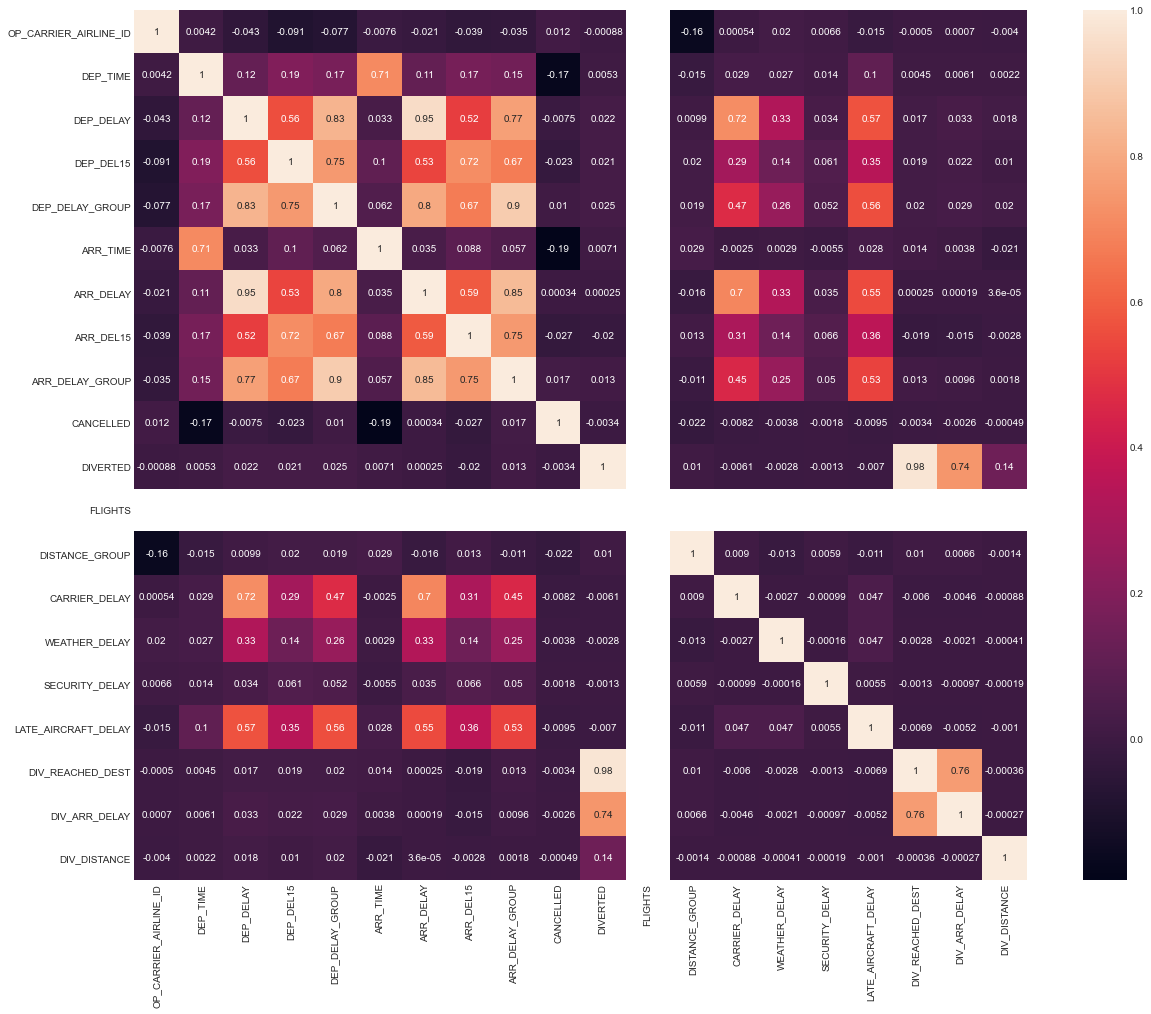

In [ ]:
import seaborn as sb
import matplotlib.pyplot as plt
pd.set_option('display.max_columns',500)
%matplotlib inline

plt.figure(figsize=(20, 16))
sb.heatmap(df_2.corr(),annot = True)

## Visualize the variable distribution with histograms

In [ ]:
df_2.hist(bins=30, figsize=(12,12), density=True)
plt.show()

NameError: ignored

# Preparing Data

In [ ]:
df_new = df_2.replace(np.nan, 0)

In [ ]:
df_new = df_new.dropna()

### If the carrier delay is larger than zero, label 1 is assigned; otherwise, label 0 is assigned.

In [ ]:
df_new[df_new['CARRIER_DELAY'] <= 0] = 0
df_new[df_new['CARRIER_DELAY'] > 0] = 1

In [ ]:
# rename the target variable as Label for easier understanding

df_new = df_new.rename(columns = {'CARRIER_DELAY' : 'Label'})

In [ ]:
# import the dataset into spark

spark_df = session.createDataFrame(df_new)

In [ ]:
# convert the numeric columns to integer type

for i in spark_df.columns :
    data_df = spark_df.withColumn(i, spark_df[i].cast(IntegerType()))

In [ ]:
# assemble all the columns into a vector matrix

feature_list = []
for col in data_df.columns:
    if col == 'Label':
        continue
    else:
        feature_list.append(col)
assembler = VectorAssembler(inputCols=feature_list, outputCol="features")

In [ ]:
df = assembler.transform(data_df)

In [ ]:
df

DataFrame[OP_CARRIER_AIRLINE_ID: bigint, ORIGIN_STATE_ABR: bigint, DEST_STATE_ABR: bigint, DEP_TIME: double, DEP_DELAY: double, DEP_DEL15: double, DEP_DELAY_GROUP: double, ARR_TIME: double, ARR_DELAY: double, ARR_DEL15: double, ARR_DELAY_GROUP: double, CANCELLED: double, DIVERTED: double, FLIGHTS: double, DISTANCE_GROUP: bigint, Label: double, WEATHER_DELAY: double, SECURITY_DELAY: double, LATE_AIRCRAFT_DELAY: double, DIV_REACHED_DEST: double, DIV_ARR_DELAY: double, DIV_DISTANCE: int, features: vector]

In [ ]:
# split the dataset into test and train

train, test = df.randomSplit([0.7, 0.3], seed = 10)

## Models

### Logistic Regression

In [ ]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(featuresCol = 'features', labelCol = 'Label', maxIter = 5)
lrModel = lr.fit(train)
predictions1 = lrModel.transform(test)

NameError: ignored

In [ ]:
predictions1.createOrReplaceTempView('predictions1')

In [ ]:
# Write the query

query1 = "SELECT sum(case when prediction = Label then 1 end)*100/count(prediction) as Logistic_Regression_Accuracy FROM predictions1"

# Run the query

q1 = session.sql(query1)
q1.show()

### Random Forest

In [ ]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(featuresCol = 'features', labelCol = 'Label')
rfModel = rf.fit(train)
predictions2 = rfModel.transform(test)

In [ ]:
predictions2.createOrReplaceTempView('predictions2')

In [ ]:
# Write the query

query2 = "SELECT sum(case when prediction = Label then 1 end)*100/count(prediction) as Random_Forest_Accuracy FROM predictions2"

# Run the query

q2 = session.sql(query2)
q2.show()

### Decision Tree

In [ ]:
from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(labelCol="Label", featuresCol="features")
dtModel = dt.fit(train)
predictions3 = dtModel.transform(test)

In [ ]:
# create a temp view for sql queries

predictions3.createOrReplaceTempView('predictions3')

In [ ]:
# Write the query

query3 = "SELECT sum(case when prediction = Label then 1 end)*100/count(prediction) as Decision_Tree_Accuracy FROM predictions3"

# Run the query

q3 = session.sql(query3)
q3.show()

### Gradient Classifier

In [ ]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(labelCol="Label", featuresCol="features", maxIter=10)
gtbModel = gbt.fit(train)
predictions4 = gtbModel.transform(test)

In [ ]:
# create a temp view for sql queries

predictions4.createOrReplaceTempView('predictions4')

In [ ]:
# Write the query

query4 = "SELECT sum(case when prediction = Label then 1 end)*100/count(prediction) as Gradient_Boost_Accuracy FROM predictions4"

# Run the query

q4 = session.sql(query4)
q4.show()